# Modelo de predicción de churn en clientes de un gimnasio

### Objetivo: Desarrollar una estrategia de retención de clientes del gimnasio Model Fitness mediante el análisis de los perfiles de clientes. 

## Paso 1. Descargar los datos

In [5]:
# Cargamos las librerías que necesitaremos:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [6]:
# Cargamos el data set, al que llamaremos churn:
churn = pd.read_csv("C:\\Users\\Alexis García\\Documents\\Alo\\Alita_TT\\CPC\\Proyectos para portafolio\\Churn\\gym_churn_us.csv")

In [7]:
# Vemos las primeras 10 filas del data set:
print("Primeras filas de churn:")
churn.head(10)

Primeras filas de churn:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
5,1,1,0,0,1,1,1,34,450.743960,1.0,3,2.623477,2.637007,0
6,1,1,1,1,0,6,1,32,94.266389,6.0,2,1.138941,1.277242,0
7,0,1,0,0,1,1,0,30,217.786641,1.0,0,1.213502,1.049387,1
8,1,1,1,1,1,1,1,23,45.409909,1.0,1,1.106239,1.059333,0
9,0,1,0,0,1,1,0,31,65.310836,1.0,11,1.810852,1.951368,0


## Paso 2. Análisis exploratorio de datos (EDA)

In [8]:
# Llamamos al método info() para ver si el data frame tiene datos ausentes en alguna columna:
print(churn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

El data frame no contiene datos ausentes en ninguna característica

In [9]:
# Usamos el método describe para ver el promedio y desviación estándar de todas las columnas:
print(churn.describe())

            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

En primer lugar, vemos que la característica gender tiene un promedio de 0.51 y una desviación estándar de 0.49. Esto significa que los datos están distribuidos casi 50/50, es decir, prácticamente la mitad de los usuarios son mujeres y la otra hombres. Respecto a la edad, observamos que el promedio es de 29.18 años. Como la desviación estándar es de 3.25, vemos que la edad de la mayoría de usuarios se acerca a este número. Por otro lado, la característica Near_Location indica que el 84% de los usuarios viven cerca del gimnasio, mientras que el 16% no. 

En cuanto a la columna Partner, el promedio es 0.48 y su desviación estándar es 0.49. Al igual que en la característica género, los datos están casi balanceados: el 48% trabaja en una compañía asociada al gimnasio y el 52%, no. 

Respecto a Promo_friends, el 30% de los clientes se inscribió con el código promocional de un/a amigo/a, y el 70% restante no lo hizo. En Phone, el promedio es de 0.90, es decir, el 90% de los usuarios aportó el número de teléfono al inscribirse, y el resto no lo hizo. También observamos que el 41% de los usuarios participa el sesiones en grupo, y el resto no lo hace. 

En la característica Contract_period, el promedio es 4.68, y la desviación estándar es de 4.54. Eso significa que hay datos que están bastante dispersos, es decir, abajo o arriba de la media. Sin embargo, los percentiles nos dicen que el 75% de los usuarios tienen una membresía de menos de 6 meses. Algo parecido pasa con la columna de Month_to_end_contract period, la cual tiene un promedio de 4.32 y una desviación estándar de 4.19. Gracias a los percentiles, vemos que al 75% de los clientes les faltan menos de 6 meses para que expire su contrato. 

Por un lado, la columna Avg_class_frequency_total tiene un promedio de 1.87 y una desviación estándar de 0.97, lo que quiere decir que la mayoría de los clientes visitan el gimnasio aproximadamente 2 veces a la semana a lo largo de su vida. Por otro lado, en el mes en curso, las visitas disminuyeron ligeramente, pues el promedio fue de 1.76.

Finalmente, estudiaremos las últimas tres características. En cuanto a Lifetime, el promedio fue de 3.72, la desviación estándar de 3.74. Dado que la desviación estándar es mayor que el promedio, podemos concluir que hay valores atípicos, es decir, clientes que llevan en el gimnasio muchos más meses. El percentil 75 indica que la mayoría de clientes tienen menos de 5 meses desde que llegaron por primera vez al gimnasio. Sin embargo, el resto lleva más tiempo. 

La característica Avg_additional_charges_total indica que en promedio, los clientes han gastado $146.94 en servicios adicionales del gimnasio. Finalmente, la característica objetivo Churn nos dice que el 26% de los usuarios canceló su suscripción en el mes en cuestión, mientras que el 44% la mantuvo. 

In [10]:
# Creamos la variable características para extraer los nombres de las columnas del data set, a excepción de nuestra característica objetivo.
caracteristicas = churn.drop('Churn', axis = 1).columns
# Usamos el método groupby para agrupar los clientes con base en los valores de la columna Churn y obtener el promedio de todas las características:
churn_0_1 = churn.groupby('Churn')[caracteristicas].mean()
print(churn_0_1)

         gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Churn                                     
0                               2.0

Aquí podemos ver varias diferencias significativas en los valores de las características en los dos grupos. Por ejemplo, vemos que de los clientes que se quedaron, el 53% trabaja en una empresa asociada, mientras que de los que se fueron, solo el 35% sí trabajaba en una empresa asociada y el otro 65%. Esto podría indicar que los usuarios que sí trabajan en una compañía asociada al gimnasio tienen más probabilidades de quedarse. 

Otra de las características donde existe una gran diferencia son las sesiones en grupo, pues el 46% de los clientes que se quedaron participaban en sesiones grupales, mientras que solo el 26% de los que cancelaron lo hacían. Es decir, el 74% no participaba en sesiones grupales, lo cual puede ser un factor predictivo de que el usuario va a cancelar. 

Finalmente, observamos que otro factor predictivo que indica si el usuario cancelará o se quedará es la duración de su membresía. Para los usuarios que no cancelaron el promedio fue de 5.74 meses, mientras que para los que sí lo hicieron fue de 1.72 meses. Aquí podríamos concluir que los clientes con una membresía más extensa son más propensos a quedarse. 

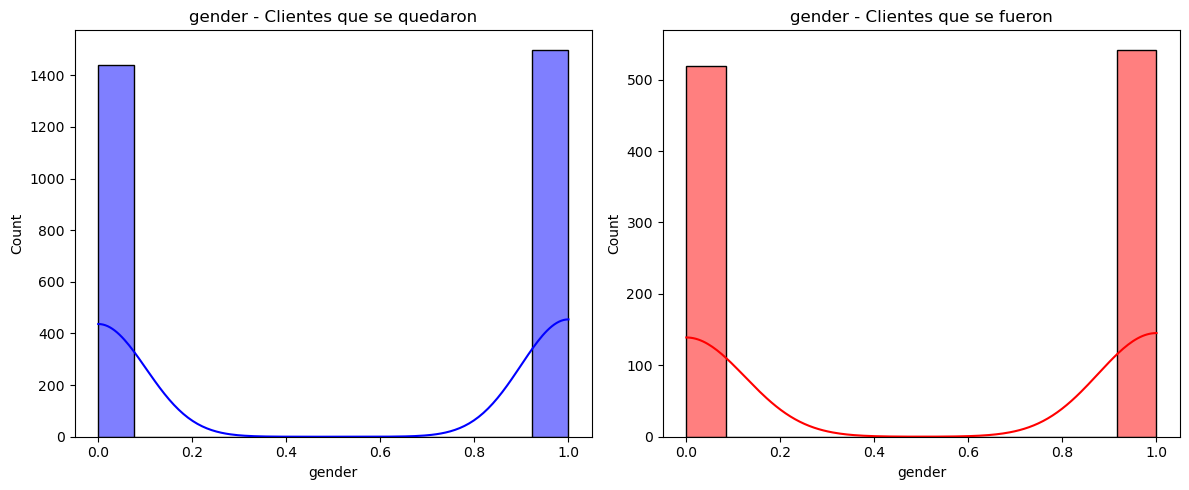

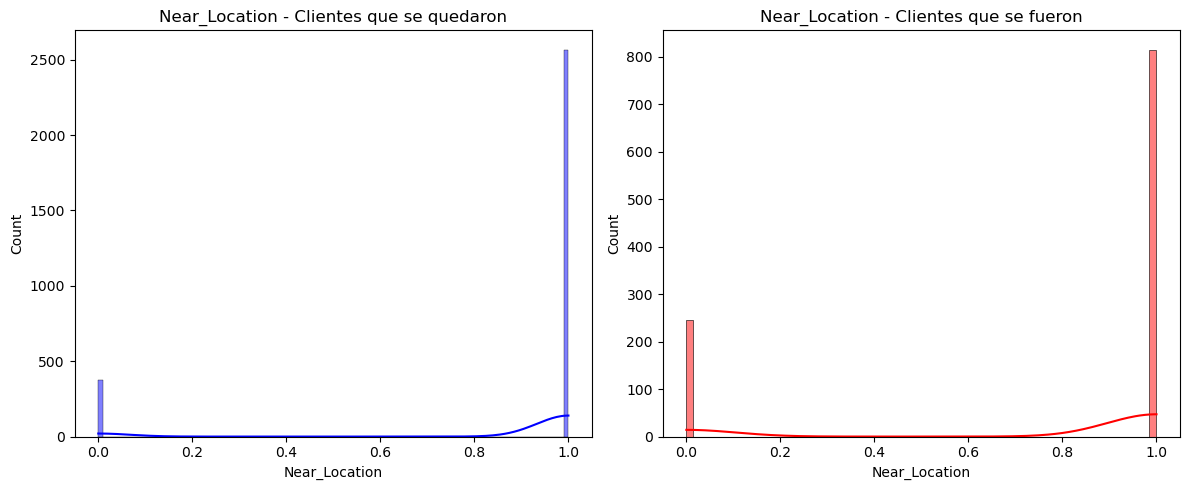

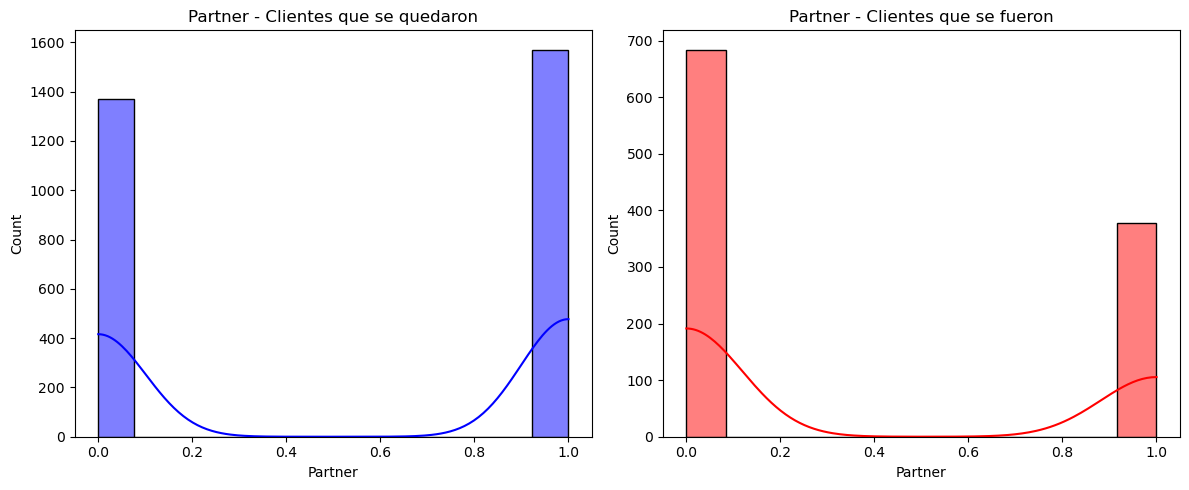

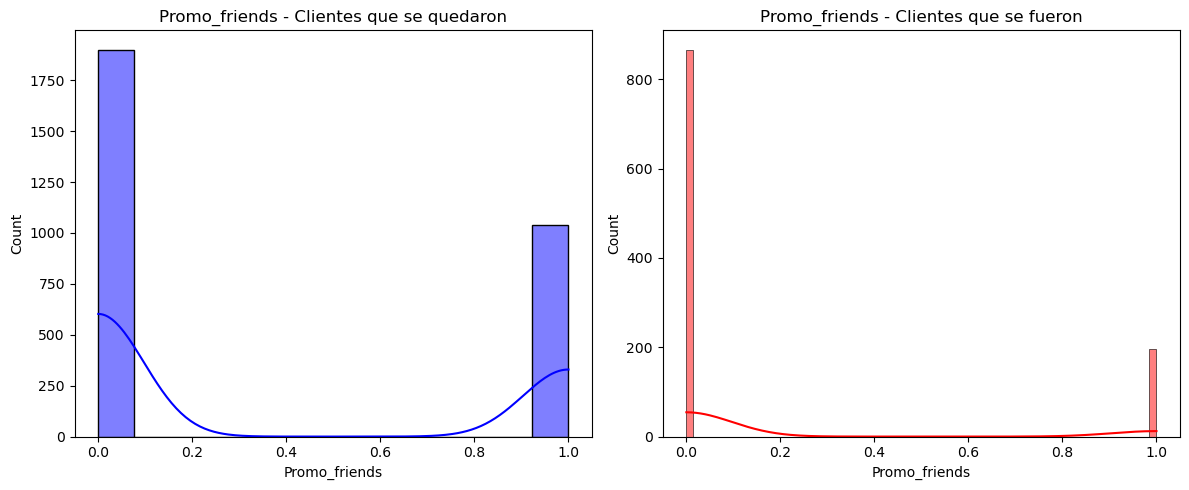

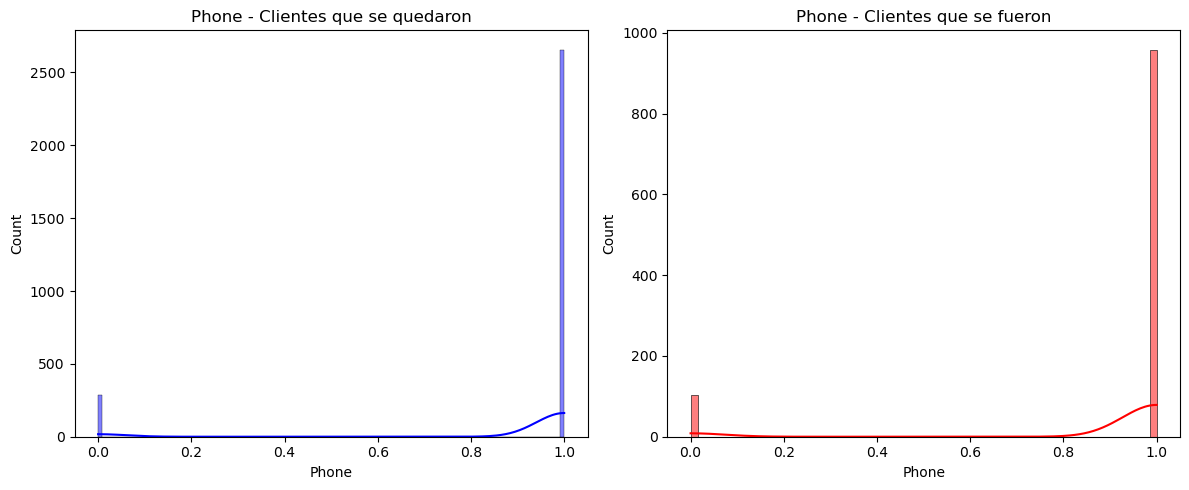

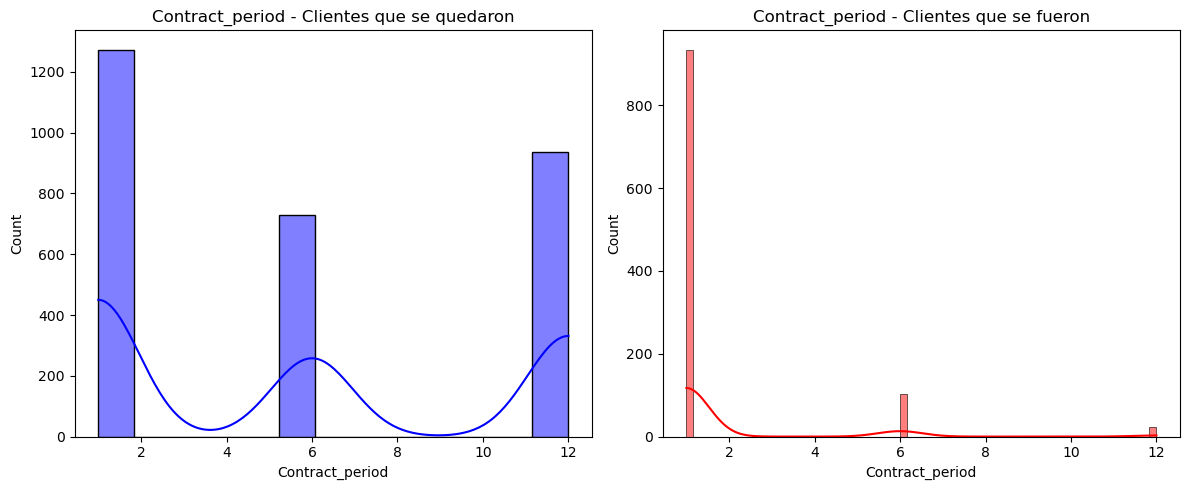

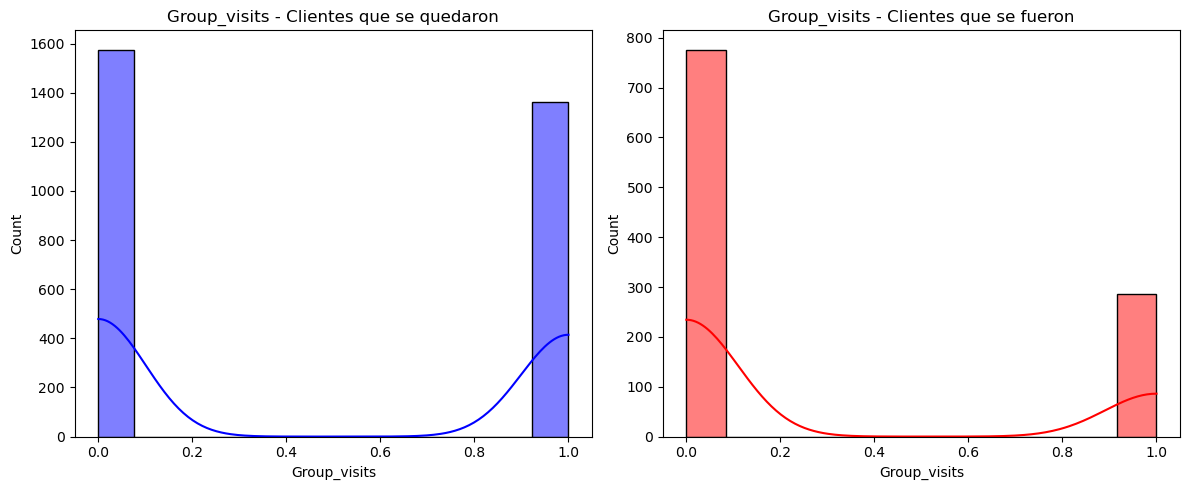

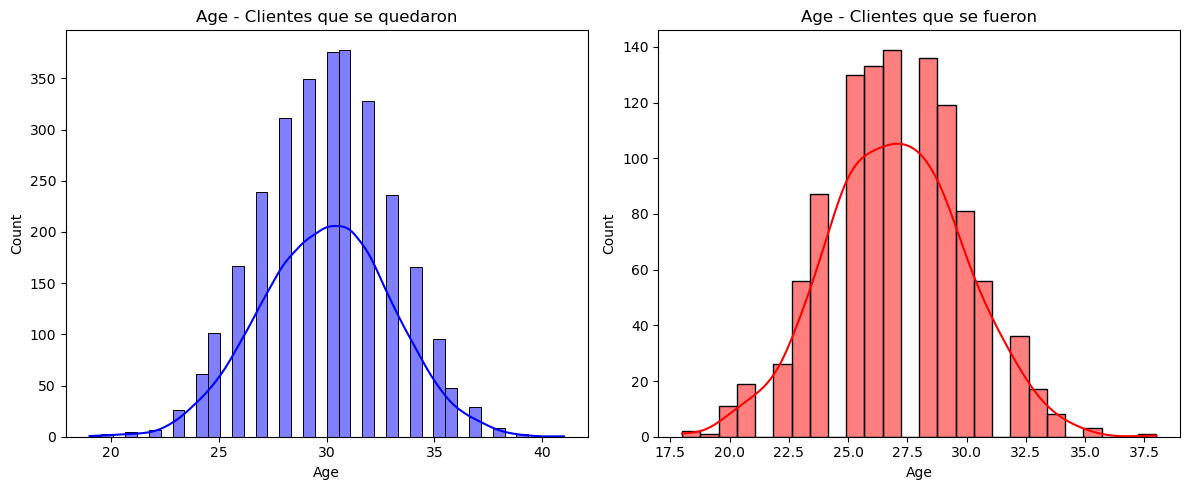

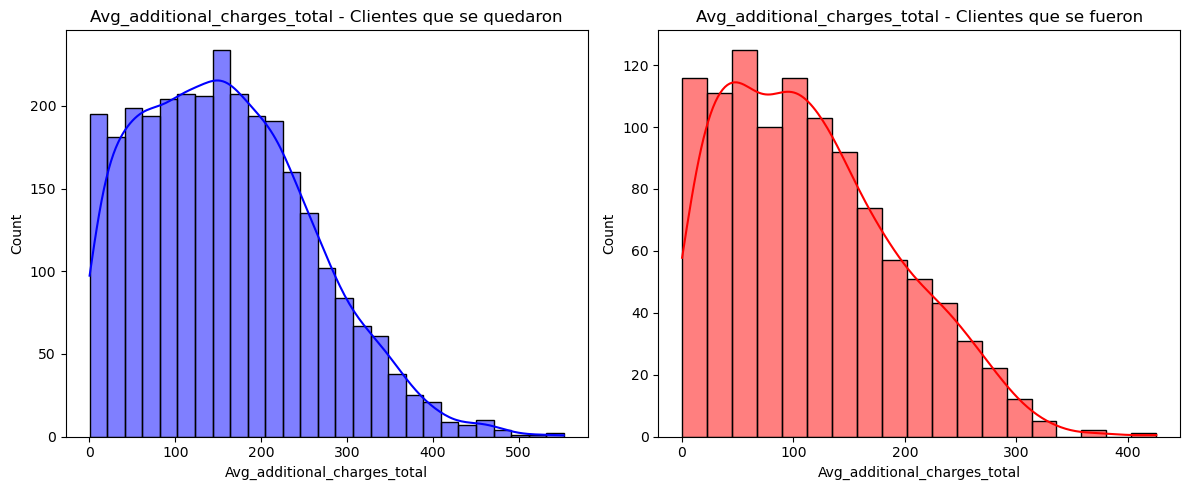

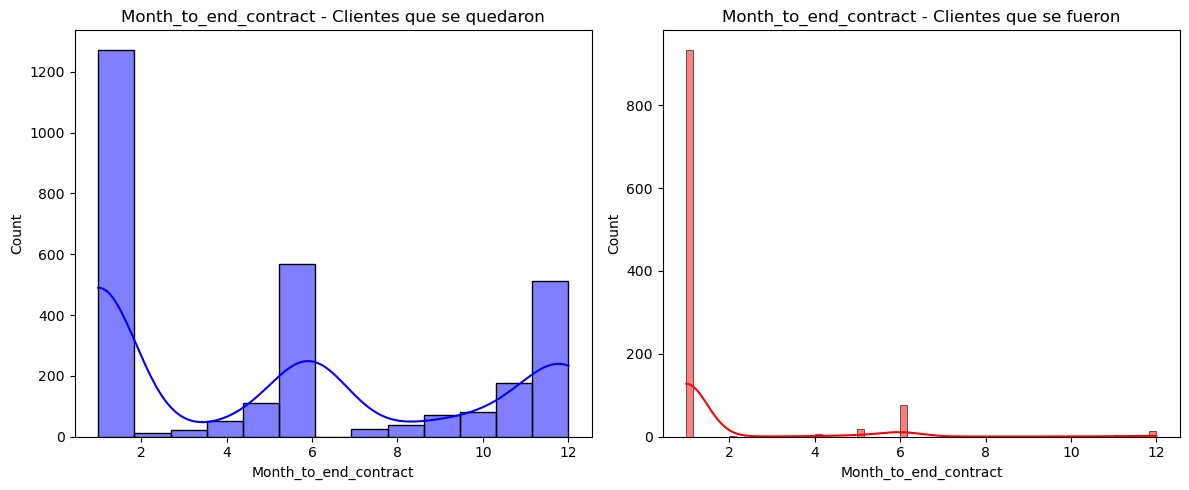

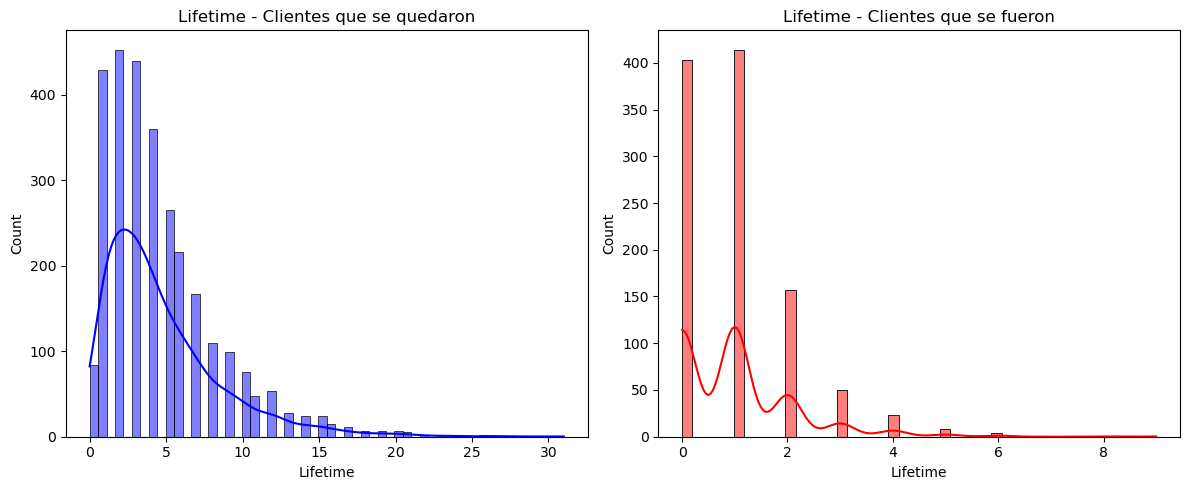

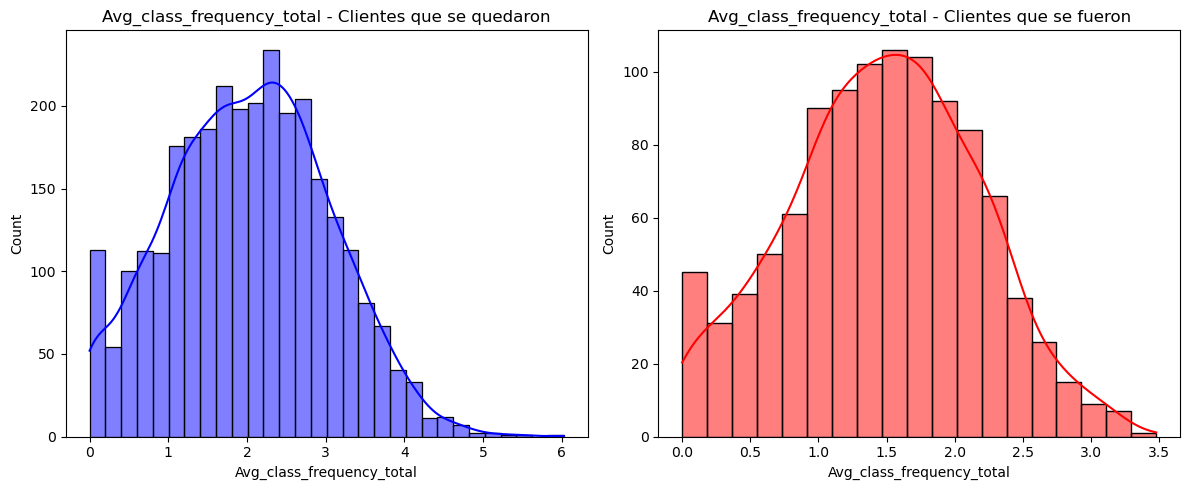

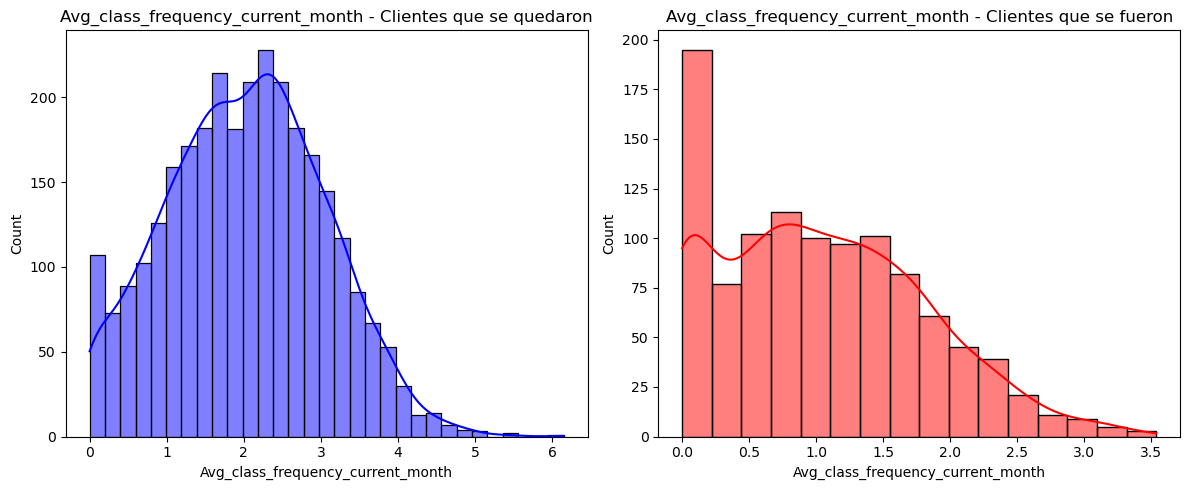

In [11]:
# Dividimos el data set en dos grupos: los clientes que se quedaron y los que cancelaron:
churn_0 = churn.query('Churn == 0')
churn_1 = churn.query('Churn == 1')


def histograma (df1, df2):
    for c in caracteristicas:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        sns.histplot(df1[c], kde=True, color='blue', ax=axes[0])
        axes[0].set_title(f'{c} - Clientes que se quedaron')
        sns.histplot(df2[c], kde=True, color='red', ax=axes[1])
        axes[1].set_title(f'{c} - Clientes que se fueron')
        plt.tight_layout()
        plt.show()


histograma(churn_0, churn_1)


Vemos que la gran mayoría de los usuarios que se van, aproximadamente 800, viven cerca del gimnasio a comparación con los que no. Esto indica que el hecho de vivir lejos del gimnasio no es un factor para que los clientes cancelen. Respecto a Promo_friends, vemos que podría influir un poco para determinar si un usuario se quedará o no. En el gráfico de los que quedaron, vemos que aproximadamente 1900 no usaron ningún código promocional, mientras que 1100 sí usaron. En cuanto a los que cancelaron, 850 no lo usaron, y 200 sí. 

Como confirmamos en la sección 2.2, el hecho de que un cliente trabaje en una empresa asociada al gimnasio influye a la hora de cancelar o no, pues la mayoría de los que se quedaron trabajan en este tipo de empresas, mientras que la mayoría de los que cancelaron, no.    

La distribución de la característica Contract_period es interesante, pues a pesar de que la mayoría de los clientes que se quedan tienen suscripciones de 1 mes, al igual que los que se fueron, observamos que también hay una cantidad considerable de clientes que tienen suscripciones de 6 y 12 meses, mientras que en el grupo que canceló, los clientes con suscripciones de 6 y 12 meses son muy pocos. Esto sigue reforzando la predicción de que los clientes con membresías largas tienen más probabilidad de quedarse.

Respecto a los gastos adicionales en el gimnasio vemos que la mayoría de los clientes que se quedaron han gastado alrededor de 150 dólares, mientras que los que cancelan han gastado menos de 120 dólares aproximadamente. También en la edad parece haber una diferencia en la distribución, pues los clientes que se quedan tienen entre 29 y 30 años, mientras que los que cancelan están entre sus 27 y 28 años. 

Otro factor interesante es el promedio de visitas. La mayoría de los clientes que se quedan tienen entre 2 y 3 visitas. Mientras que los que cancelan tienen menos de 2 visitas. Esto podría indicar que los clientes que visitan el gimnasio 2 o más veces a la semana tienen más probabilidades de quedarse. 

### Matriz de correlación

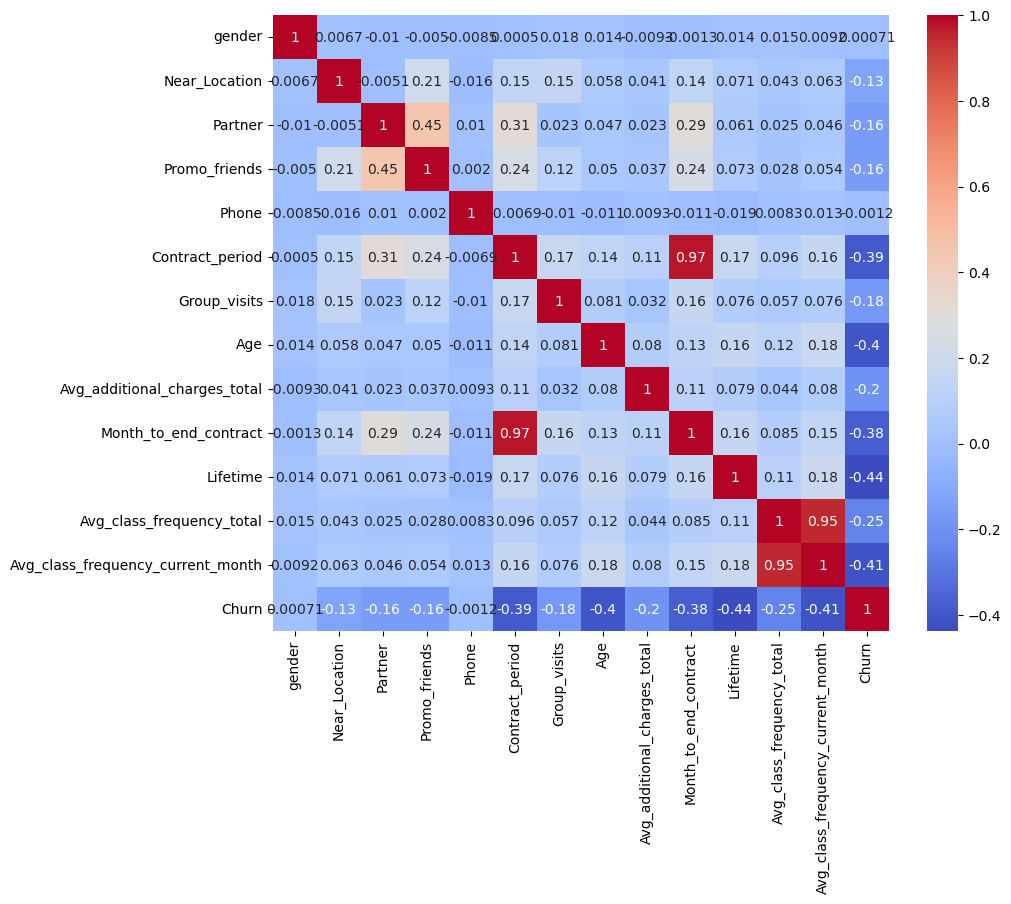

In [12]:
# Creamos un matriz de correlación:
corr_churn = churn.corr()
# Creamos un diagrama de calor para visualizarla:
plt.figure(figsize = (10,8))
sns.heatmap(corr_churn, cmap = 'coolwarm', square = True, annot = True)
plt.show()

Vemos una correlación negativa especialmente en las siguientes características: Contract_period, Age, Month_to_end_contract, Lifetime, y Average_class_frequency_current_month. Esto nos puede hacer llegar a las siguientes conclusiones:

* Entre más extenso sea el contrato, es menos probable que el usuario cancele
* Entre mayor sea el cliente, es menos probable que cancele
* Entre más meses falten para que termine el contrato, es menos probable que el usuario cancele
* Entre más tiempo lleve el cliente en el gimnasio, es menos probable que cancele
* Entre más clases a la semana asista el cliente, es menos probable que se vaya

## Paso 3. Construir un modelo para predecir la cancelación de usuarios


In [13]:
# Dividimos los datos en características (la matriz X) y una variable objetivo (y)
X = churn.drop('Churn', axis = 1)
y = churn['Churn']
# Dividimos los datos en entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#### Regresión logística

In [14]:
# Creamos un objeto StandardScaler y lo aplicamos al conjunto de entrenamiento
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train) 
# Aplicamos la estandarización a la matriz de característica para el test de prueba:
X_test_st = scaler.transform(X_test)
# Creamos el modelo:
rl_model = LogisticRegression(random_state=0)
# Entrenamos el modelo:
rl_model.fit(X_train_st, y_train)
# Predicción binaria:
rl_predictions = rl_model.predict(X_test_st)

#### Bosque aleatorio

In [15]:
# Definimos el algoritmo:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 0)
# Entrenamos el modelo de random forest
rf_model.fit(X_train_st, y_train)
# Utilizamos el modelo entrenado para hacer previsiones:
rf_predictions = rf_model.predict(X_test_st)

In [16]:
def print_all_metrics(y_true, y_pred, title = 'Métricas de'):
    print(title)
    print('\tAccuracy: {:.2f}'.format(accuracy_score(y_true, y_pred)))
    print('\tPrecision: {:.2f}'.format(precision_score(y_true, y_pred)))
    print('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))

print_all_metrics(y_test, rl_predictions, title = 'Métricas de regresión logística')
print_all_metrics(y_test, rf_predictions, title = 'Métricas de bosque aleatorio')

Métricas de regresión logística
	Accuracy: 0.92
	Precision: 0.85
	Recall: 0.83
Métricas de bosque aleatorio
	Accuracy: 0.92
	Precision: 0.84
	Recall: 0.81


Observamos que ambos modelos tienen la misma puntuación en accuracy. Sin embargo, el de regresión logística tiene una precisión y recall más altos que el del bosque aleatorio. En lo personal, opino que sería más conveniente priorizar el recall, ya que los falsos negativos son más costosos. Queremos identificar a los clientes que tienen más probabilidad de irse y tomar medidas preventivas, y no nos conviene que el modelo prediga que el cliente se quedará cuando en realidad se irá. Por esta razón, el modelo de regresión logística parece ser la mejor opción.

## Paso 4. Crear clústeres de usuarios/as

In [17]:
# Creamos un objeto StandardScaler y lo aplicamos a X, la variable que no contiene la columna Churn.
sc = StandardScaler()
x_sc = sc.fit_transform(X)

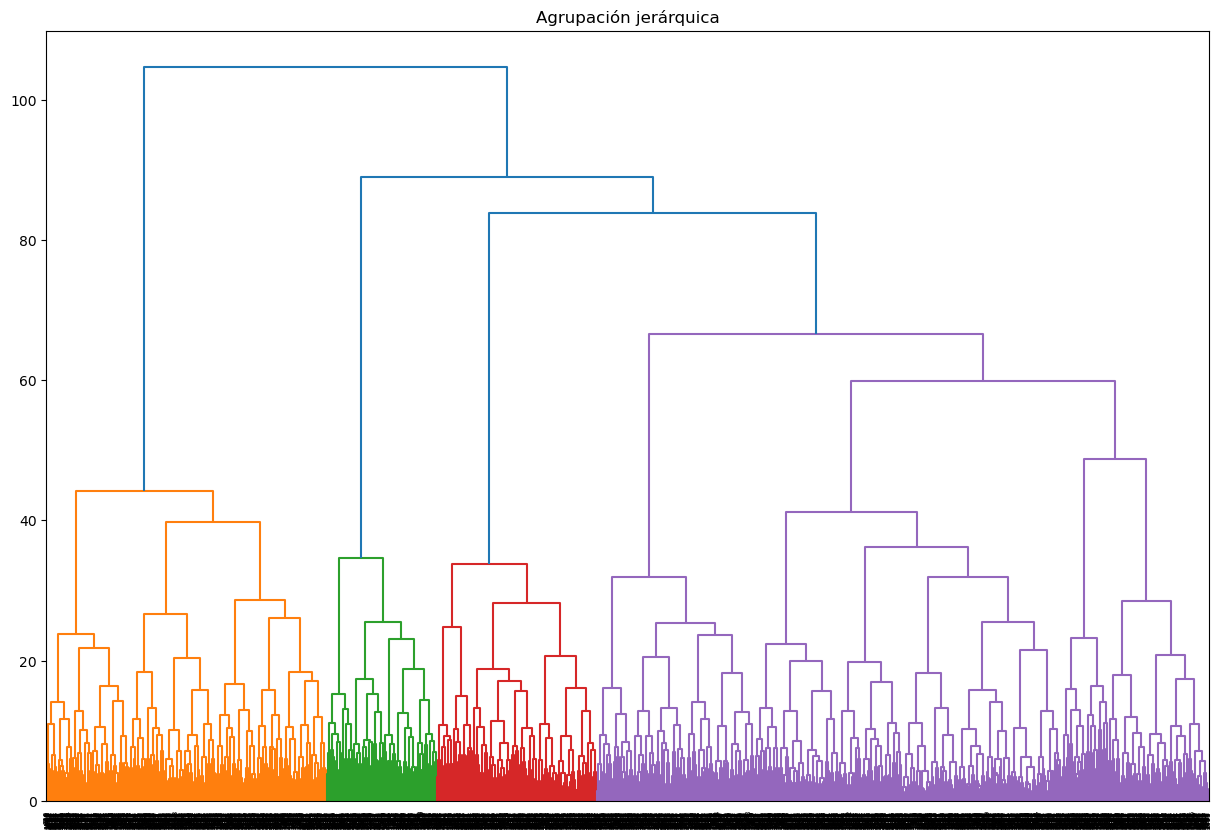

In [18]:
# Utilizamos la función linkage() para crear una matriz de distancias basada en la matriz de características estandarizada y trazar un dendrograma. 
linked = linkage(x_sc, method = 'ward')
#Creamos un dendograma para visalizar la tabla:
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Agrupación jerárquica')
plt.show()

En el dendograma resultante podemos ver 4 colores diferentes, es decir, 4 clústeres. Sin embargo, considero que el de color morado es bastante grande, por lo que podríamos incrementarlo a 5 o 6 clústeres. 

In [19]:
# Entrenamos el modelo de clustering con el algortimo K-means. Establecemos el número de clústeres en 5:
km = KMeans(n_clusters = 5, random_state=0)
# Aplicamos el algoritmo a los datos:
labels = km.fit_predict(x_sc) 

In [20]:
# Agregamos las etiquetas de clúster a Churn:
churn['cluster_km'] = labels
# Agrupamos por clúster para ver los valores medios:
cluster_groupped = churn.groupby('cluster_km')[caracteristicas].mean()
print(cluster_groupped)

              gender  Near_Location   Partner  Promo_friends     Phone  \
cluster_km                                                               
0           0.486819       1.000000  0.243409       0.007030  0.899824   
1           0.592493       0.970509  0.288204       0.123324  0.898123   
2           0.499469       0.943677  0.740701       0.489904  0.900106   
3           0.483360       1.000000  0.798732       1.000000  0.911252   
4           0.496324       0.000000  0.466912       0.077206  0.915441   

            Contract_period  Group_visits        Age  \
cluster_km                                             
0                  1.978910      0.326889  28.239016   
1                  2.898123      0.482574  30.339142   
2                 11.866100      0.551541  29.905420   
3                  3.079239      0.445325  29.052298   
4                  2.209559      0.215074  28.483456   

            Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
cluster_km 

En la característica de gender, vemos que los datos están prácticamente balanceados 50/50. Por otro lado, en near_location, ningún usuario vive cerca del gimnasio en el clúster 2, mientras que en el clúster 3, sucede lo contrario. 

En el clúster 0, tenemos la tasa de usuarios más alta que usaron un código promocional cuando se inscribieron (57%), mientras que en el 2, la más baja (7%). 

También es interesante que en la columna phone, prácticamente todos los clusters tuvieron una tasa del 100%, a excepción del 1, donde ningún usuario proporcionó su teléfono. 

Vemos que el promedio de contract_period para el clúster 0 fue de 10.88, lo que indica que este grupo prefiere los contratos más extensos, seguido del clúster 1, con un promedio de 4.78. Por el contrario, el clúster 3 tiene un promedio de 1.94, el más bajo. El segundo más bajo es el del clúster 2, con 2.35.

En cuanto a la edad, el clúster 4 tiene un promedio de 30.12, el cual es el más alto, lo que quiere decir que es el grupo de usuarios con más edad. Le sigue el clúster 0, con 29.98, luego el 1 con 29.30, después el 2 con 28.47, y finalmente el clúster 3 con 28.16.

Los clústeres con los promedios más altos en la columna Avg_additional_charges_total fueron el 4 y el 0 con 161.65 y 160.76, respectivamente. Los que menos gastaron fueron los grupos 3 y 2, quienes gastaron 131.62 y 135.45. 

Los grupos con los usuarios que asisten a más clases, tanto en promedio total como en el mes en cuestión, fueron el 4 y el 0. Los que asistieron a menos clases fueron el 2 y 3. 

Vemos que el clúster que le faltaban más meses para finalizar su contrato fue el 0, con 9.95 meses en promedio, seguido del 1, con 4.47 meses. Por otro lado, los clústeres con menos meses antes de la finalización del contrato fueron el 2 y el 3. 

Finalmente, los clusters que llevaban más meses en el gimnasio fueron el 4 y el 0. con 4.89 y 4.73 en promedio, respectivamente. Los grupos que llevaban menos tiempo fueron el 3 y el 2, con 2.44 y 2.80.

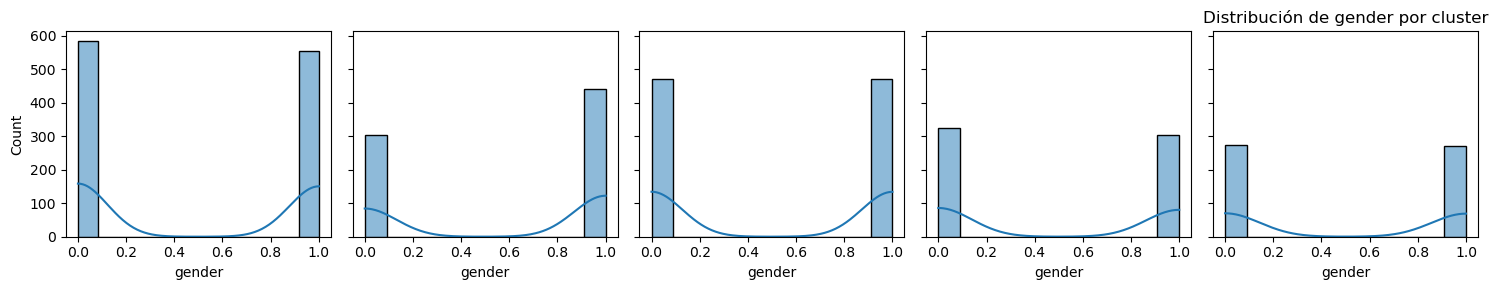

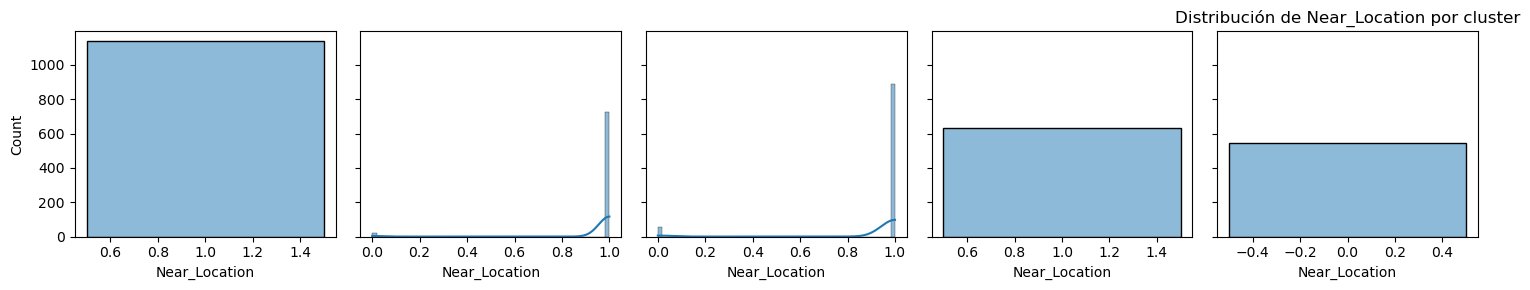

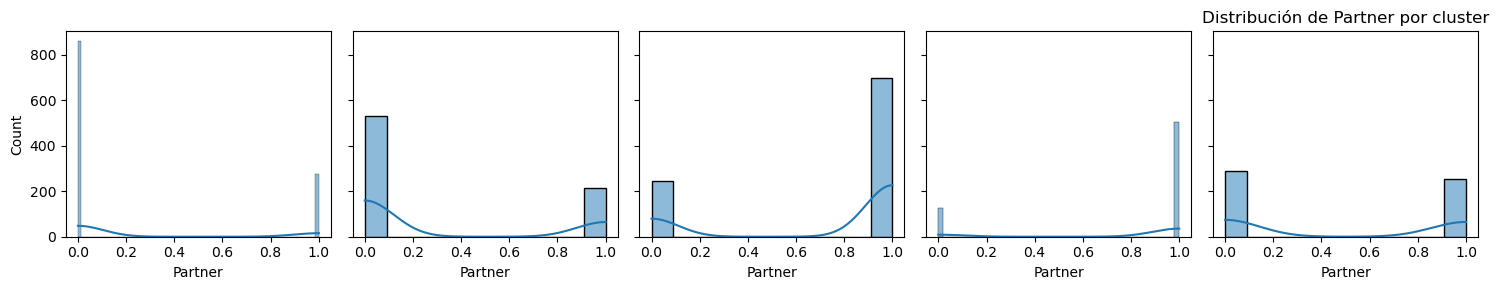

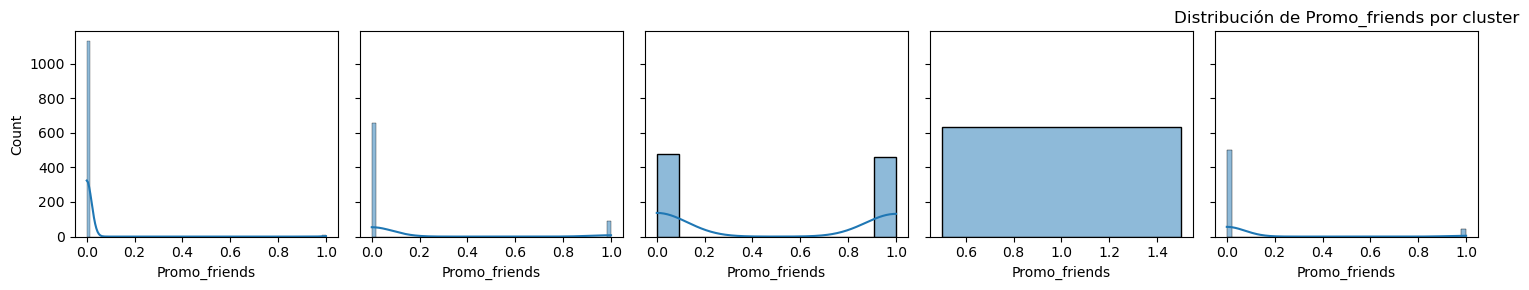

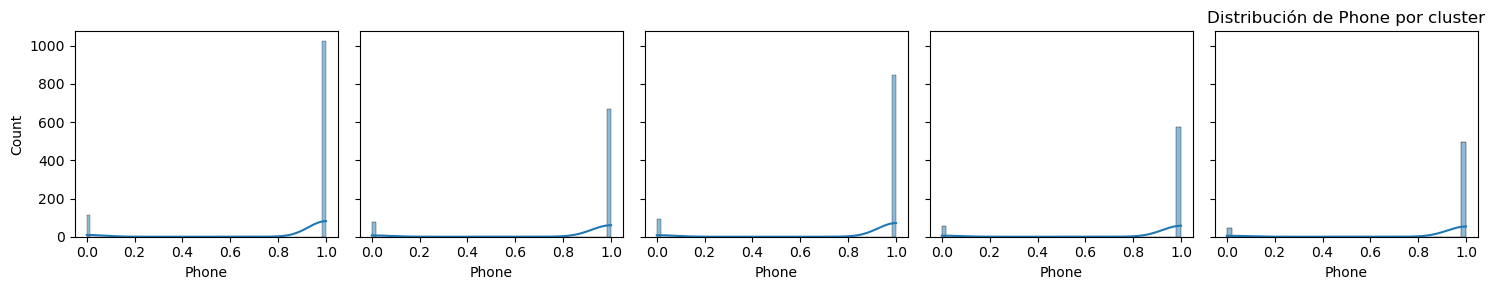

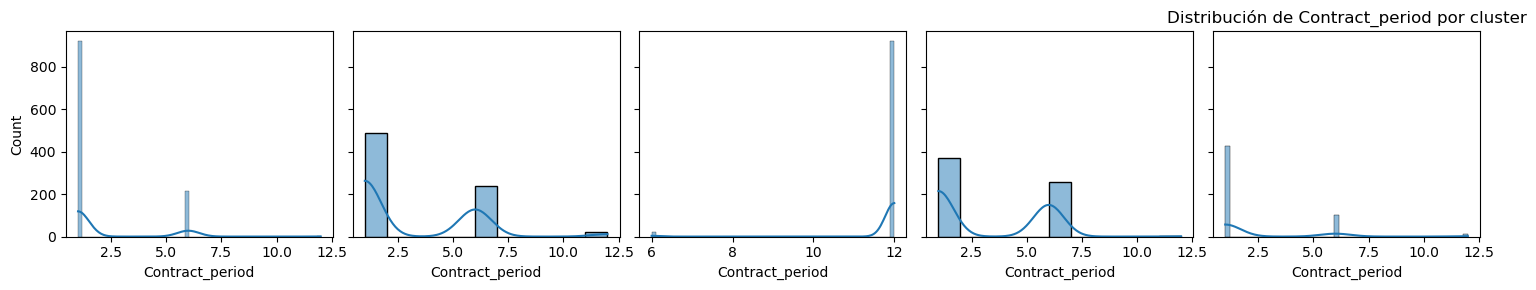

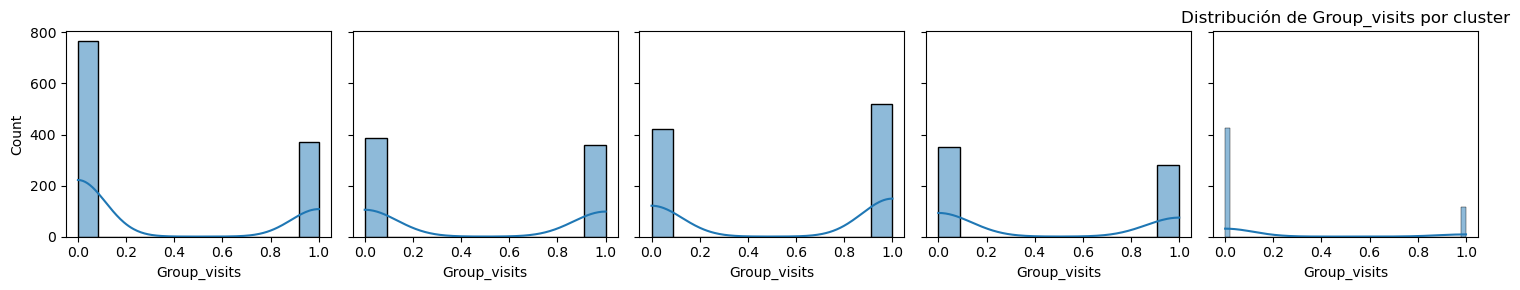

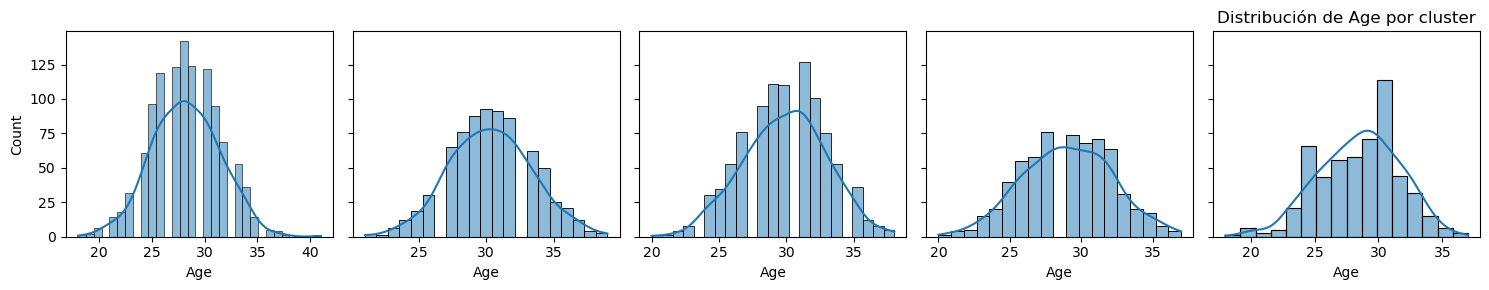

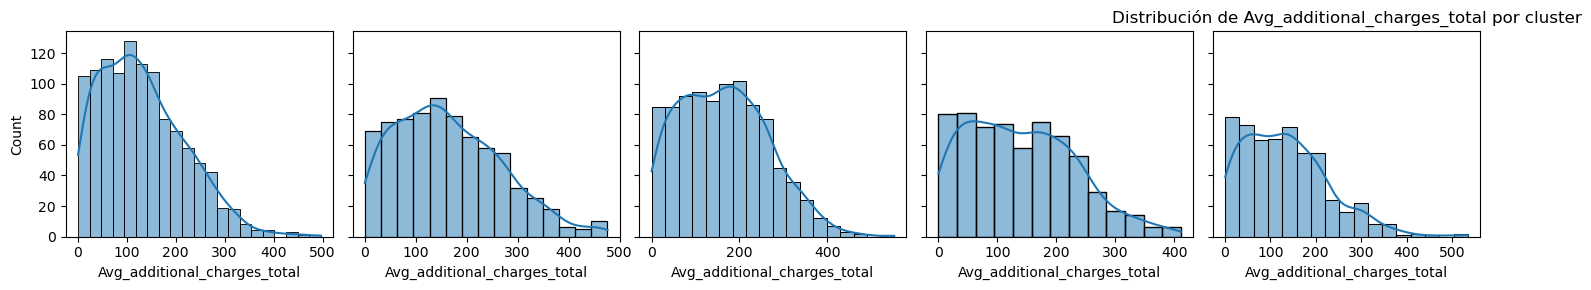

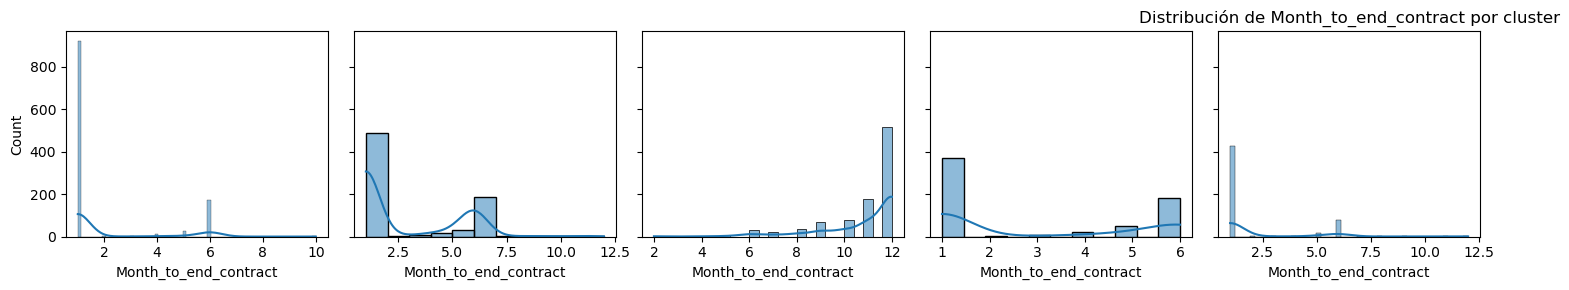

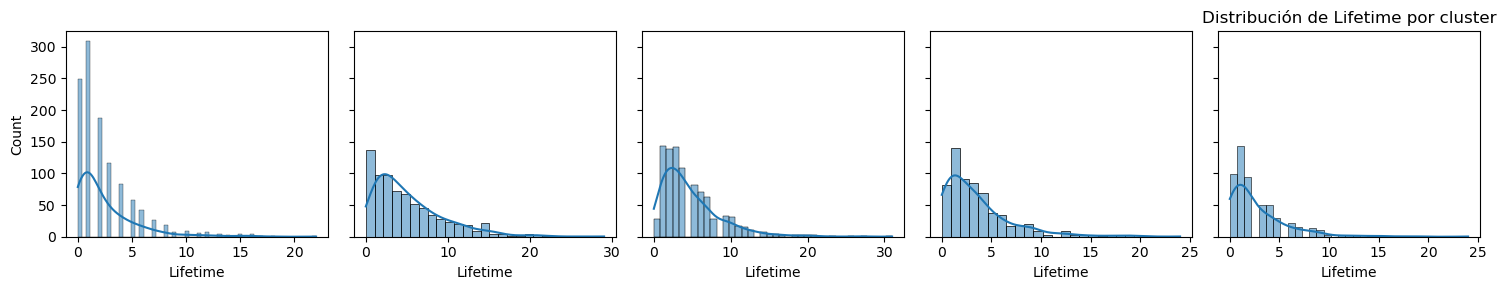

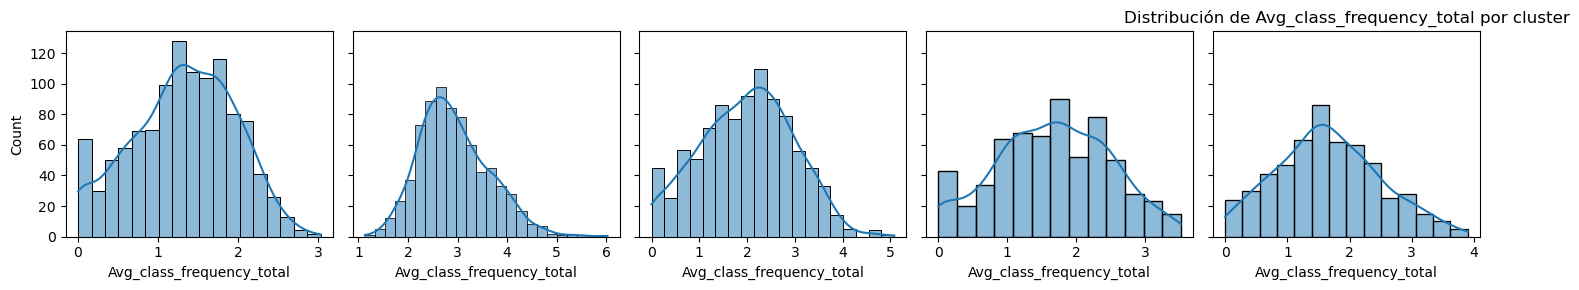

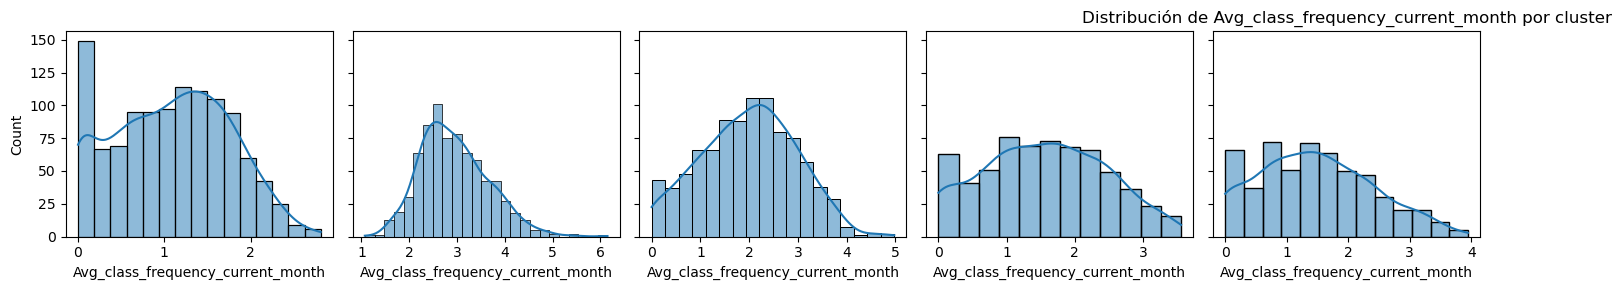

In [21]:
# Dividimos el data set para trazar los histogramasen los cinco clústeres:
c_0 = churn.query('cluster_km == 0')
c_1 = churn.query('cluster_km == 1')
c_2 = churn.query('cluster_km == 2')
c_3 = churn.query('cluster_km == 3')
c_4 = churn.query('cluster_km == 4')

for c in caracteristicas:
    fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
    sns.histplot(c_0[c], ax=axes[0], kde=True)
    sns.histplot(c_1[c], ax=axes[1], kde=True)
    sns.histplot(c_2[c], ax=axes[2], kde=True)
    sns.histplot(c_3[c], ax=axes[3], kde=True)
    sns.histplot(c_4[c], ax=axes[4], kde=True)
    plt.title(f'Distribución de {c} por cluster')
    plt.tight_layout()
    plt.show()


Algo interesante es la distribución en Contract_period. En los clústeres 2 y 3, vemos una distribución muy parecida: la mayoría de clientes tienen contratos de 1 mes, algunos de 6 meses y muy pocos de 12. Por otro lado, en el clúster 0, solo hay clientes con contratos de 6 y 12 meses, siendo este último el que tiene más incidencias. El clúster 1, tiene una distribución parecida a la de los clústeres 2 y 3, solo que la frecuencia de contratos con un mes es mucho mayor. Finalmente, el clúster 4, tiene casi la misma cantidad de clientes con 1, 6 y 12 meses. En conclusión, el clúster 0 tiene los usuarios con los contratos más extensos, mientras que el 1, tiene a los usuarios con contratos de solo 1 mes. 

En age, vemos que en el clúster 0, la mayoría de clientes están entre sus 30 y 32 años. En el 3, la distribución es bastante parecida a la del clúster 0. En el 1, donde tenemos a los más jóvenes, la mayoría tiene entre 27 y 29 años aproximadamente. Aunque cabe señalar que también tenemos a unos cuantos usuarios menores de 20. En el 2, vemos que la mayoría tiene entre 27 y 30 años. Finalmente, el 4, observamos que los datos tienen poca variación. En conclusión, los clústeres con los usuarios de más edad son los 0 y 3, y en el clúster 1 tenemos a los más jóvenes.

En el histograma del promedio de clases en total, en el clúster 3, tenemos una gran cantidad de clientes que han asistido a 2 clases, algunos a 3 y pocos de 4 a 6. En el 1, hay varios clientes que no han asistido a ninguna, y la gran mayoría ha asistido solo a 1 clase, y pocos a 2 clases. En el clúster 0, la mayoría de clientes ha asistido a 2 clases. Sin embargo, también vemos varios usuarios que algunos han asistido 3, y pocos a 4 y 5. En el 2, la mayoría ha asistido a 1 clase, y también tenemos a algunos que asistieron a 2 y 3. Finalmente, en el grupo 4, de nuevo observamos poca variación y tenemos a varios clientes que han asistido a 1 y 2 clases. En conclusión, los clústeres con los clientes que han asistido a más clases, al menos 2, son el 0 y el 3, y el clúster con la peor asistencia es el 1, con la mayoría de usuarios asistiendo a una sola clase. 

Finalmente, el lifetime, observamos que en el clúster 0, la mayoría de clientes llevan entre 1 y 3 meses en el gimnasio; sin embargo, hay algunos que llevan más, incluso hasta 30 meses. En el 1, observamos que la gran mayoría lleva entre 0 y 1 mes. En el 2, la mayoría lleva 1 mes, y de ahí la frecuencia va bajando hasta 25 meses. La distribución del clúster 3 se parece bastante a la del clúster 0. Y finalmente, en el 4, la mayoría lleva 0 meses, es decir, que se acaban de inscribir. Sin embargo, también tenemos a algunos que llevan de 1 a 5 meses, y así hasta llegar a 25. En conclusión, los clientes con un mayor tiempo de vida en el gimnasio son los del clúster 0 y 3, y los que llevan menos tiempo son los del 1.

cluster_km
0    0.513181
1    0.054960
2    0.022317
3    0.269414
4    0.450368
Name: Churn, dtype: float64


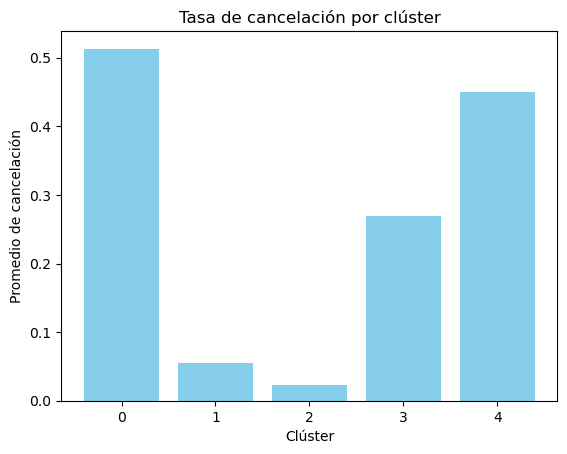

In [22]:
# Agrupamos por clúster y calculamos el promedio de la columna Churn:
cluster_churn = churn.groupby('cluster_km')['Churn'].mean()
print(cluster_churn)
# Trazamos un gráfico de barras:
plt.bar(color='skyblue', x = cluster_churn.index, height = cluster_churn.values)
plt.xlabel('Clúster')
plt.ylabel('Promedio de cancelación')
plt.title('Tasa de cancelación por clúster')
plt.show()

El grupo con la tasa de cancelación más alta fue el 1, con una tasa del 57%. Por otro lado, los grupos más leales, es decir, con la tasa de cancelación más baja fueron el 0  y el 3, con 2% y 8%, respectivamente. Los clústeres 2 y 4 tuvieron tasas de cancelación muy parecidas: 24% y 26%, respectivamente. 

## Paso 5 Conclusiones y recomendaciones

En primer lugar, dado que el el clúster 0 demostró tener la mayor cantidad de contratos extensos en el histograma, el cual tuvo la tasa de cancelación más baja, y el clúster 3, el grupo con la tasa más alta, tuvo la mayor cantidad de contratos de un mes, podemos concluir que entre más corto sea el contrato, el cliente tiene más probabilidad de irse. Esto sucede porque cuando el cliente solo paga un mes, se le hace más fácil cancelar ya que no pagó un contrato más extenso. También podemos llegar a la conclusión de que si un cliente paga un contrato de 6 o 12 meses, este es más propenso a quedarse y no cancelar. 

En segundo lugar, la edad también resultó ser un factor predictivo, ya que los clústeres 0 y 3, aquellos con la tasa de cancelación más baja, tienen a los usuarios con más edad, es decir, usuarios entre 30 y 32 años. Mientras que el grupo con usuarios más jóvenes, aquellos entre 27 y 29 años, fue el clúster 1, el cual tuvo la tasa de cancelación más alta. En conclusión, entre más jóvenes sean los usuarios, más probabilidad tienen de cancelar. 

En tercer lugar, los clústeres con el mayor lifetime (1 a 3 meses en su mayoría, y algunos clientes hasta 30 meses) fueron el 0 y el 3. Mientras que los que llevan menos tiempo, menos de un mes en su mayoría, pertenecen al clúster 1. Esto indica que entre más tiempo lleve un usuario en el gimnasio, es menos probable que cancele. 

Finalmente, el cuarto factor importante es el número de clases, ya que los usuarios que asistieron a más clases pertenecen a los clústeres con las tasas más bajas de cancelación. Asimismo, los usuarios que asistieron a menos clases fueron de los clústeres con las tasas más altas. Para ser exactos, los clientes que asisten a al menos 2 o 3 clases tienen más probabilidad de quedarse, mientras que aquellos que asisten a 1 o ninguna son más propensos a cancelar. 

Para disminuir la tasa de cancelación, sería esencial hacer que los clientes escojan un contrato de más de un mes, de preferencia, de 6 o 12 meses. Para esto, el gimnasio podría implementar descuentos atractivos en membresías de 6 y 12 meses, o agregar algún beneficio exclusivo si los clientes eligen este tipo de planes, por ejemplo, un masaje gratuito a la semana o servicio de lockers gratuito.

Para mantener a los clientes más jóvenes, quienes son estudiantes en su mayoría, podríamos ofrecerles descuentos especiales de estudiantes si escogen el plan de 6 o 12 meses. También, es más probable que los jóvenes tengan más motivación para ir al gimnasio si van con un amigo, por lo que podríamos implementar la oferta de 2x1/2 si ambos eligen el plan de 12 meses.

Para fomentar la lealtad de los usuarios que apenas van comenzando, habría que mejorar la atención al cliente y comunicación, lo cual es esencial para que un nuevo miembro se sienta bienvenido y acompañado. Por ejemplo, responder rápidamente a sus consultas y comentarios, y entrenar al personal para que siempre tenga la mejor actitud con el cliente, en especial si es nuevo. También sería importante crear una comunidad para que los clientes interactúen y conecten mediante eventos mensuales, desafíos y actividades sociales. 

Finalmente, para aumentar la asistencia a clases, podríamos ofrecer disciplinas en tendencia, en especial para las mujeres, como pilates, barré o cardio jump. También podríamos crear retos y dar puntos a los clientes que asistan a un determinado número de clases al mes, los cuales podrán canjear por productos deportivos o suplementos. 